1.0
[[15  0]
 [ 0 15]]


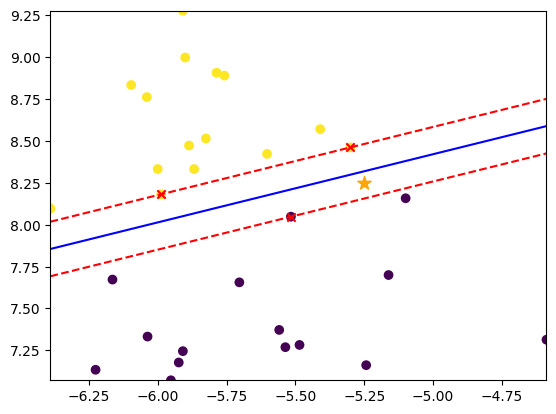

[-0.42119405]
[0]


In [1]:
from sklearn.datasets import make_blobs, make_circles, make_classification
from sklearn.svm import SVC, SVR
import pandas as pd
import numpy as np
from sklearn import metrics
from matplotlib import pyplot as plt
import time

X, Y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

SVM_lin = SVC(kernel='linear', C=1000)
SVM_lin.fit(X, Y)
pred = SVM_lin.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))

def plot_decision_regions(X, Y, model):
    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    vectors = model.support_vectors_

    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.contour(X0_grid, X1_grid, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors=['r', 'b', 'r'])
    plt.scatter(vectors[:, 0], vectors[:, 1], marker='x', c='red')
    plt.show()


observation_new = [[-5.25, 8.25]]
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, Y, SVM_lin)

print(SVM_lin.decision_function(observation_new))
print(SVM_lin.predict(observation_new))

1.0
[[15  0]
 [ 0 15]]


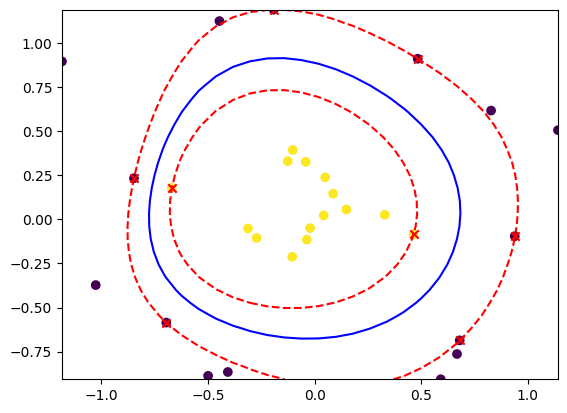

In [2]:
X, Y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

SVM_rbf = SVC(kernel='rbf', C=100)
SVM_rbf.fit(X, Y)
pred = SVM_rbf.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrixconfusion_matrix(Y, pred))

vectors = SVM_rbf.support_vectors_


plot_decision_regions(X, Y, SVM_rbf)

0.7
[[ 7  8]
 [ 1 14]]


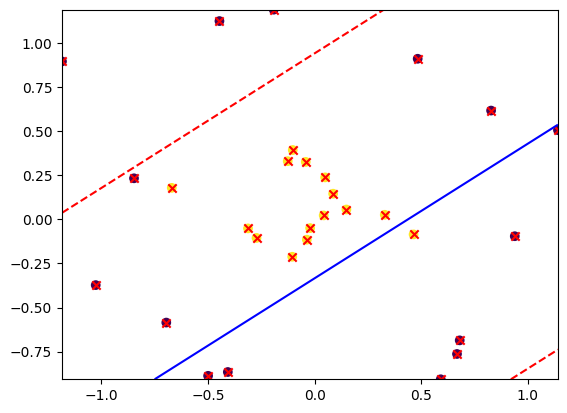

In [3]:
SVM_rbf = SVC(kernel='linear')
SVM_rbf.fit(X, Y)
pred = SVM_rbf.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))

vectors = SVM_rbf.support_vectors_


plot_decision_regions(X, Y, SVM_rbf)

0.7
[[ 6  9]
 [ 0 15]]


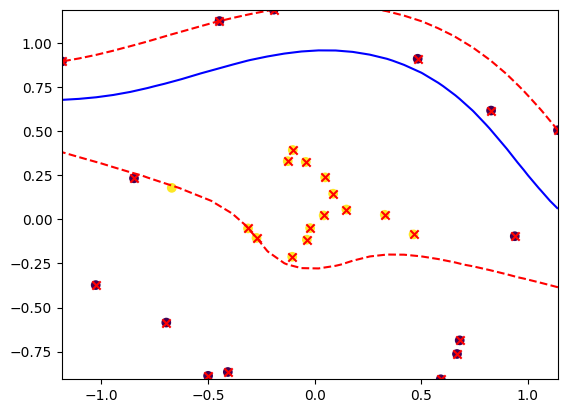

In [4]:
SVM_rbf = SVC(kernel='poly')
SVM_rbf.fit(X, Y)
pred = SVM_rbf.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))

vectors = SVM_rbf.support_vectors_


plot_decision_regions(X, Y, SVM_rbf)

0.9333333333333333
[[13  2]
 [ 0 15]]


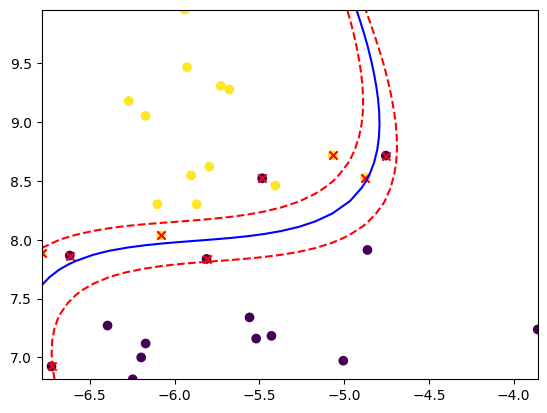

In [5]:
X, Y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

SVM_poly = SVC(kernel='poly', degree=4, C=10000000)
SVM_poly.fit(X, Y)
pred = SVM_poly.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))

plot_decision_regions(X, Y, SVM_poly)


0.7666666666666667
[[13  2]
 [ 5 10]]


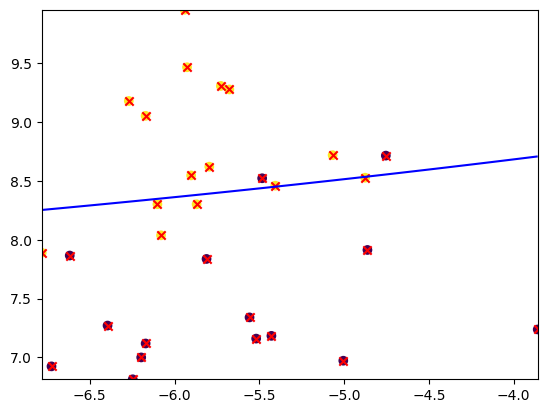

In [6]:
SVM_poly = SVC()
SVM_poly.fit(X, Y)
pred = SVM_poly.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))

plot_decision_regions(X, Y, SVM_poly)

0.8
[[11  4]
 [ 2 13]]


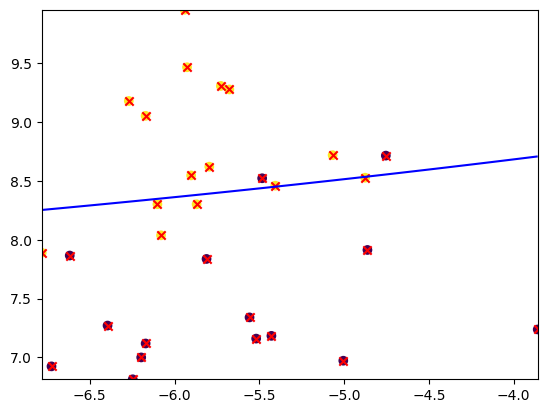

In [7]:
from sklearn.svm import LinearSVC

LinSvc = LinearSVC()
LinSvc.fit(X, Y)
pred = LinSvc.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))

plot_decision_regions(X, Y, SVM_poly)


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X, Y = make_classification(n_features=5, n_samples=1000, n_classes=2, class_sep=2, random_state=5)

parm = {
    'svm__kernel': ['linear', 'poly', 'rbf'],
    'svm__C': [0.01, 0.1, 1, 10, 100],
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

grid = GridSearchCV(pipeline, param_grid=parm, scoring='accuracy', n_jobs=-1, cv=5)
grid.fit(X, Y)

print(grid.best_params_)


{'svm__C': 100, 'svm__kernel': 'rbf'}


1.0
[[34  0  0]
 [ 0 33  0]
 [ 0  0 33]]


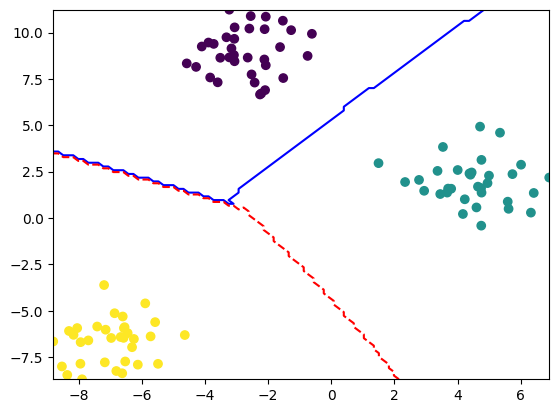

In [9]:
X, Y = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=5, gamma="scale"))
])
model.fit(X, Y)
pred = model.predict(X)
print(metrics.accuracy_score(Y, pred))
print(metrics.confusion_matrix(Y, pred))


def plot_decision_regions(X, Y, model):
    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    grid = np.c_[X0_grid.ravel(), X1_grid.ravel()]
    Z = model.predict(grid).reshape(X0_grid.shape)

    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.contour(X0_grid, X1_grid, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors=['r', 'b', 'r'])
    plt.show()

plot_decision_regions(X, Y, model)

0.82
[[50  0  0]
 [ 0 38 12]
 [ 0 15 35]]


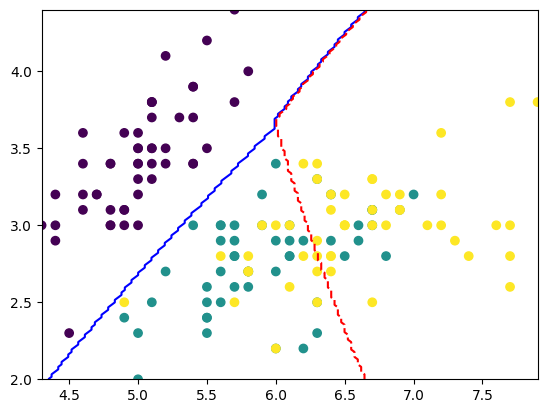

In [15]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data[:, :2]
y = iris.target

model = SVC(kernel="rbf", C=1)
model.fit(X, y)
pred = model.predict(X)
print(metrics.accuracy_score(y, pred))
print(metrics.confusion_matrix(y, pred))
plot_decision_regions(X, y, model)

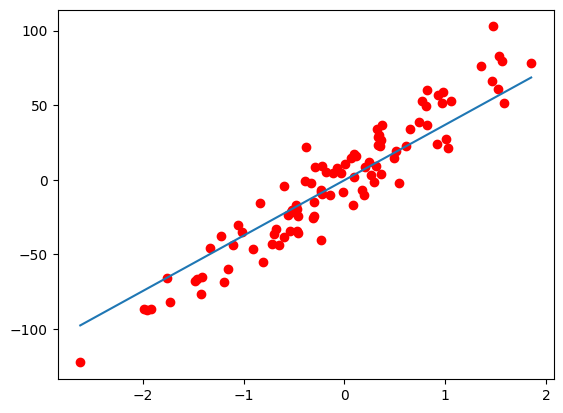

0.8739135694138496


In [11]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
model = SVR(kernel='linear', C=1)
model.fit(X, y)
model.fit(X, y)
pred = model.predict(X)

X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_plot = model.predict(X_plot)

plt.scatter(X, y, c='r')
plt.plot(X_plot, y_plot)
plt.show()

print(model.score(X, y))